In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords

from sklearn.svm import SVC
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
# Загрузка данных
df = pd.read_csv('data.csv')

In [43]:
df.head()

,tokenize_text
0,бухгалтер энди дюфрейн обвинить убийство собст...
1,пол эджкомба начальник блок смертник тюрьма хо...
2,лицо главное герой форрест гампа слабоумный бе...
3,фильм рассказывать реальный история загадочный...
4,пострадать результат несчастный случай богатый...


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tokenize_text  250 non-null    object
dtypes: object(1)
memory usage: 2.1+ KB


## Векторизация текста

In [48]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный']) 

In [50]:
# TF-IDF векторизация
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")

Размер TF-IDF матрицы: (250, 1849)
Количество признаков: 1849


## Определение оптимального количества кластеров

In [53]:
from sklearn.decomposition import NMF

In [55]:
# создание модели NMF
nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: жизнь, друг, мир, ребёнок, мочь, весь, девушка, год, стать, жить
Topic 1: холмс, шерлок, шерлок холмс, ватсон, доктор, доктор ватсон, схватка, мориарти, убийца, холмс доктор ватсон
Topic 2: война, фильм, человек, судьба, время, герой, сын, год, мировой, мировой война
Topic 3: марти, машина, подросток, время, машина время, попадать, док, 80х, браун, помощь
Topic 4: джек, элизабет, уилла, капитан, воробей, джек воробей, проклятие, уилла тернера элизабет, тернера, тернера элизабет


In [77]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: жизнь, человек, мочь, год, весь, мир, жить, герой, судьба, самый
Topic 1: шерлок, шерлок холмс, холмс, ватсон, доктор, доктор ватсон, схватка, мориарти, убийца, холмс доктор ватсон
Topic 2: война, фильм, мировой, сын, мировой война, время, бой, второй мировой, судьба, второй мировой война
Topic 3: марти, машина, подросток, время, машина время, попадать, док, 80х, браун, помощь
Topic 4: ребёнок, отец, мальчик, мир, сын, получать, дочь, старший, дом, брат
Topic 5: друг, друг друг, стать, девушка, вражда, год, однажды, любовь, новый, парень
Topic 6: джек, элизабет, уилла, капитан, джек воробей, воробей, проклятие, тернера элизабет суонна, уилла тернера элизабет, уилла тернера


0: ' 0 - герой, судьба человека',
1: ' 1 – шерлок холмс, детектив',
2: ' 2 – вторая мировая война, драма',
3: ' 3 – машина времени, фантастика',
4: ' 4 – семья, семейные отношения',
5: ' 5 – любовь, романтика',
6: ' 6 – приключения, пираты',

In [79]:
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

In [83]:
df.head(10)

,tokenize_text,topic_nmf
0,бухгалтер энди дюфрейн обвинить убийство собст...,0
1,пол эджкомба начальник блок смертник тюрьма хо...,0
2,лицо главное герой форрест гампа слабоумный бе...,0
3,фильм рассказывать реальный история загадочный...,2
4,пострадать результат несчастный случай богатый...,0
5,кобба талантливый вор хороший хороший опасный ...,0
6,профессиональный убийца леон знающий пощада жа...,5
7,величественный короляльва муфас рождаться насл...,5
8,сотрудник страховой компания страдать хроничес...,5
9,инженеризобретатель тимофеев сконструировать м...,3


In [104]:
df['topic_nmf'].value_counts()

topic_nmf
0    102
2     42
4     39
5     33
3     14
1     11
6      9
Name: count, dtype: int64

Расчет метрик для разных K...
Обработка K=2...
  K=2: WCSS=242.48, Silhouette=0.0015
Обработка K=3...
  K=3: WCSS=241.17, Silhouette=0.0012
Обработка K=4...
  K=4: WCSS=239.94, Silhouette=0.0011
Обработка K=5...
  K=5: WCSS=238.50, Silhouette=0.0014
Обработка K=6...
  K=6: WCSS=237.23, Silhouette=0.0011
Обработка K=7...
  K=7: WCSS=235.93, Silhouette=0.0016
Обработка K=8...
  K=8: WCSS=234.40, Silhouette=0.0023
Обработка K=9...
  K=9: WCSS=233.05, Silhouette=0.0023
Обработка K=10...
  K=10: WCSS=231.74, Silhouette=0.0026


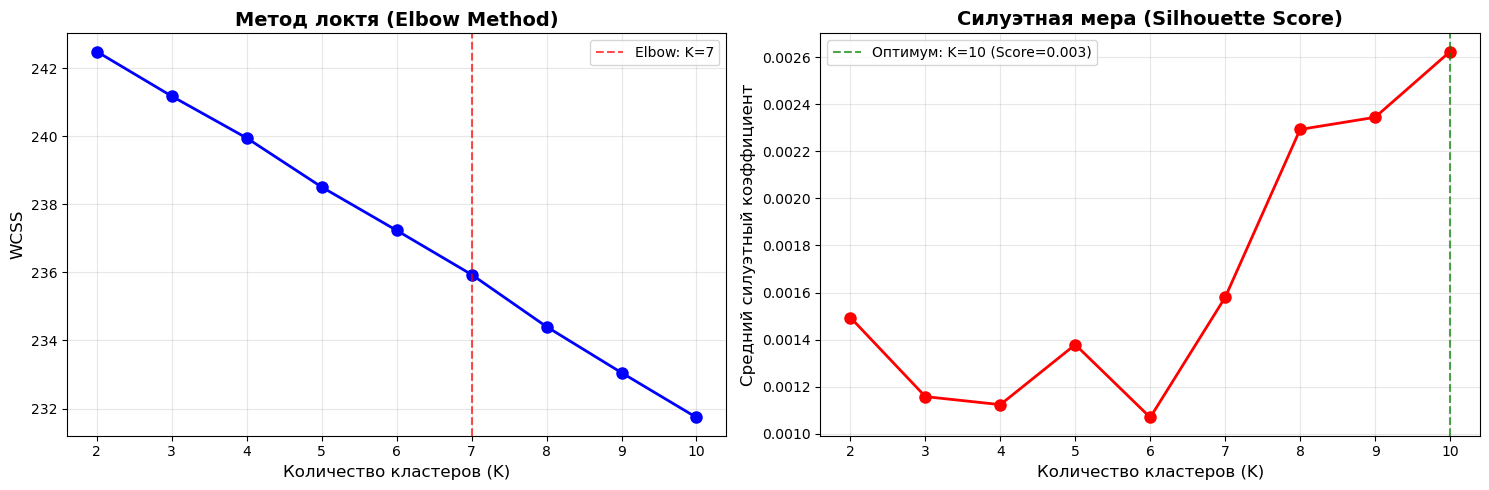


ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 10
Лучший силуэтный коэффициент: 0.0026

Интерпретация:
✗ Случайная кластеризация


In [33]:
# Расчет WCSS и силуэтных оценок
wcss = []
silhouette_scores = []

# Для силуэта нужно минимум 2 кластера
K_range = range(2, 11)  # От 2 до 10 кластеров

print("Расчет метрик для разных K...")
for k in K_range:
    print(f"Обработка K={k}...")
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    
    # WCSS
    wcss.append(kmeans.inertia_)
    
    # Силуэтная мера (на выборке, так как полная матрица может быть большой)
    if tfidf_matrix.shape[0] > 5000:
        # Для больших данных берем выборку
        sample_size = min(5000, tfidf_matrix.shape[0])
        indices = np.random.choice(tfidf_matrix.shape[0], sample_size, replace=False)
        silhouette_avg = silhouette_score(tfidf_matrix[indices], cluster_labels[indices])
    else:
        silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Метод локтя
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.grid(True, alpha=0.3)

# Находим точку перегиба (elbow)
if len(wcss) > 2:
    deltas = np.diff(wcss)
    delta2_deltas = np.diff(deltas)
    elbow_k = K_range[np.argmin(delta2_deltas) + 1] if len(delta2_deltas) > 0 else K_range[np.argmin(deltas)]
    ax1.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow: K={elbow_k}')
    ax1.legend()

# Силуэтная мера
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Силуэтная мера (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Средний силуэтный коэффициент', fontsize=12)
ax2.grid(True, alpha=0.3)

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', alpha=0.7, 
            label=f'Оптимум: K={best_k_silhouette} (Score={best_score:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()

# Выбор оптимального K
optimal_k = best_k_silhouette  # Используем optimal_k = best_k_silhouette
print(f"\n{'='*50}")
print(f"ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {optimal_k}")
print(f"{'='*50}")
print(f"Лучший силуэтный коэффициент: {best_score:.4f}")
print(f"\nИнтерпретация:")
if best_score > 0.7:
    print("✓ Отличная кластеризация")
elif best_score > 0.5:
    print("✓ Хорошая кластеризация")
elif best_score > 0.25:
    print("⚠ Слабая кластеризация")
else:
    print("✗ Случайная кластеризация")

## Классификация

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['tokenize_text'], df['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [90]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [96]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [98]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [100]:
y_pred = model_lr.predict(X_test_tfidf)

In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      1.00      0.63        32
           1       0.00      0.00      0.00         3
           2       1.00      0.23      0.38        13
           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25        14
           5       1.00      0.08      0.15        12

    accuracy                           0.51        75
   macro avg       0.58      0.24      0.24        75
weighted avg       0.72      0.51      0.41        75



In [106]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [108]:
y_pred = model_rf.predict(X_test_tfidf)

In [110]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.97      0.76        32
           1       1.00      0.67      0.80         3
           2       0.89      0.62      0.73        13
           3       0.00      0.00      0.00         1
           4       1.00      0.29      0.44        14
           5       0.90      0.75      0.82        12

    accuracy                           0.72        75
   macro avg       0.73      0.55      0.59        75
weighted avg       0.79      0.72      0.69        75



In [112]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [114]:
y_pred = model_knn.predict(X_test_tfidf)

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.81      0.73        32
           1       1.00      0.67      0.80         3
           2       0.50      0.77      0.61        13
           3       0.00      0.00      0.00         1
           4       0.67      0.29      0.40        14
           5       0.75      0.50      0.60        12

    accuracy                           0.64        75
   macro avg       0.60      0.51      0.52        75
weighted avg       0.66      0.64      0.62        75



## Сохранение моделей

In [119]:
import pickle

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

In [121]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [123]:
df.to_csv('data_movies2.csv')

## Проверка модели

In [152]:
import pickle
import joblib
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer

In [166]:
with open('model_rf.pkl', 'rb') as file:
    model = pickle.load(file)

with open('vectorizer.pkl', 'rb') as file:
    vectorizer = pickle.load(file)

In [128]:
def fun_punctuation_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

In [130]:
def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        p = pymorphy3.MorphAnalyzer(lang='ru').parse(word)[0]
        res.append(p.normal_form)  
    text = " ".join(res)
    return text

In [132]:
def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [148]:
t1 = "Один ушлый американец ещё со студенческих лет приторговывал наркотиками, а теперь придумал схему нелегального обогащения с использованием поместий обедневшей английской аристократии и очень неплохо на этом разбогател. Другой пронырливый журналист приходит к Рэю, правой руке американца, и предлагает тому купить киносценарий, в котором подробно описаны преступления его босса при участии других представителей лондонского криминального мира — партнёра-еврея, китайской диаспоры, чернокожих спортсменов и даже русского олигарха."

In [140]:
t2 = "21 июня 1941 года. Молодой лейтенант Коля Плужников, получив назначение на постоянное место службы, приезжает в Брест. Переполненные залы ожидания вокзала и толпа увешанных багажом людей не настораживают охваченного радостными надеждами юношу. Коля спешит к месту расположения своей части — в Брестскую крепость… Солдата не успевают зачислить в личный состав военнослужащих, а в четыре утра раздаются артиллерийские разрывы — началась война. Он не был зачислен в ряды военнослужащих Брестской крепости, но всё равно принял участие в бою."

In [142]:
t3 = "Российский ракетный подводный крейсер специального назначения бесследно исчезает во время секретной миссии в Гренландском море. На его поиски отправляется экипаж под командованием Виктора Воронина, чей старший брат командовал пропавшей субмариной. Перед моряками стоит задача любыми силами найти подлодку и не допустить, чтобы новое секретное оружие попало в руки врага. В это же время из-за геологических исследований на полярной станции в северных водах пробуждается Кракен — гигантское чудовище, способное сливаться с подводной тьмой, обладающее высоким интеллектом. Именно с ним предстоит столкнуться морякам, разыскивающим пропавшую подводную лодку."

In [174]:
t4 = "Пострадав в результате несчастного случая, богатый аристократ Филипп нанимает в помощники человека, который менее всего подходит для этой работы, – молодого жителя предместья Дрисса, только что освободившегося из тюрьмы. Несмотря на то, что Филипп прикован к инвалидному креслу, Дриссу удается привнести в размеренную жизнь аристократа дух приключений."

In [178]:
t5 = "Жизнь харизматичного авантюриста, капитана Джека Воробья, полная увлекательных приключений, резко меняется, когда его заклятый враг капитан Барбосса похищает корабль Джека Черную Жемчужину, а затем нападает на Порт Ройал и крадет прекрасную дочь губернатора Элизабет Свонн. Друг детства Элизабет Уилл Тернер вместе с Джеком возглавляет спасательную экспедицию на самом быстром корабле Британии, чтобы вызволить девушку и заодно отобрать у злодея Черную Жемчужину. Вслед за этой парочкой отправляется амбициозный коммодор Норрингтон, который к тому же числится женихом Элизабет.Однако Уилл не знает, что над Барбоссой висит вечное проклятие, при лунном свете превращающее его с командой в живых скелетов. Проклятье будет снято лишь тогда, когда украденное золото Ацтеков будет возвращено пиратами на старое место."

In [144]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    probabilities = model.predict_proba(text_vectorized)
    return prediction, probabilities

In [168]:
prediction, probabilities = predict_topic(t1)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 5
Вероятности: [[0.27 0.02 0.01 0.03 0.   0.66 0.01]]


In [169]:
prediction, probabilities = predict_topic(t2)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 2
Вероятности: [[0.32 0.   0.55 0.   0.04 0.04 0.05]]


In [170]:
prediction, probabilities = predict_topic(t3)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.56 0.   0.15 0.05 0.11 0.04 0.09]]


In [176]:
prediction, probabilities = predict_topic(t4)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.95 0.   0.   0.   0.04 0.   0.01]]


In [180]:
prediction, probabilities = predict_topic(t5)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 6
Вероятности: [[0.16 0.01 0.05 0.   0.01 0.09 0.68]]


In [ ]:
0: ' 0 - герой, судьба человека',
1: ' 1 – шерлок холмс, детектив',
2: ' 2 – вторая мировая война, драма',
3: ' 3 – машина времени, фантастика',
4: ' 4 – семья, семейные отношения',
5: ' 5 – любовь, романтика',
6: ' 6 – приключения, пираты',